# Hello world for applied vibration analysis

## About

This notebook provides reference examples to get you up and running quickly

### Import the libraries

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import numpy as np
import math
from datetime import datetime, timedelta, timezone
from scipy import signal
import matplotlib

### Import the signal processing library

In [2]:
from appvib import ClSigFeatures

#### Verify help and class structure

Uncomment the line below to get the help listing for the plotting functin

In [3]:
#help(ClSigFeatures)

### Define plot mode. 
Interactive mode is helpful for visuallizing the program execution

In [4]:
#%matplotlib widget

### Plot a sinuosid

In this test a simple sin wave, assumed to have units of acceleration (g's), is created and passed into the signal feature object for processing

#### Create the data for plotting

In [5]:
d_fs_even = 2048
i_ns = (d_fs_even*2)
d_freq_sig = 10./(float(i_ns)/d_fs_even)
print('Signal frequency, hertz: ' + '%0.10f' % d_freq_sig)
d_time_ext = np.linspace(0,(i_ns-1),i_ns)/float(d_fs_even)
np_d_test_even = np.sin(2 * math.pi * d_freq_sig * d_time_ext )

Signal frequency, hertz: 5.0000000000


#### Create the analysis object

The applied analysis object stores data and data attributes. In the next few sections, we will access methods of the object to visualize the data. 

In [6]:
ClSigEven = ClSigFeatures(np_d_test_even, d_fs_even,
    dt_timestamp=datetime.fromisoformat('2020-01-01T00:00:00-00:00'))
ClSigEven.str_plot_desc = "Sinusoid"
ClSigEven.str_machine_name_set("Simulated Data", idx=0)
ClSigEven.str_eu_set("g's",idx=0)

#### Timebase plot

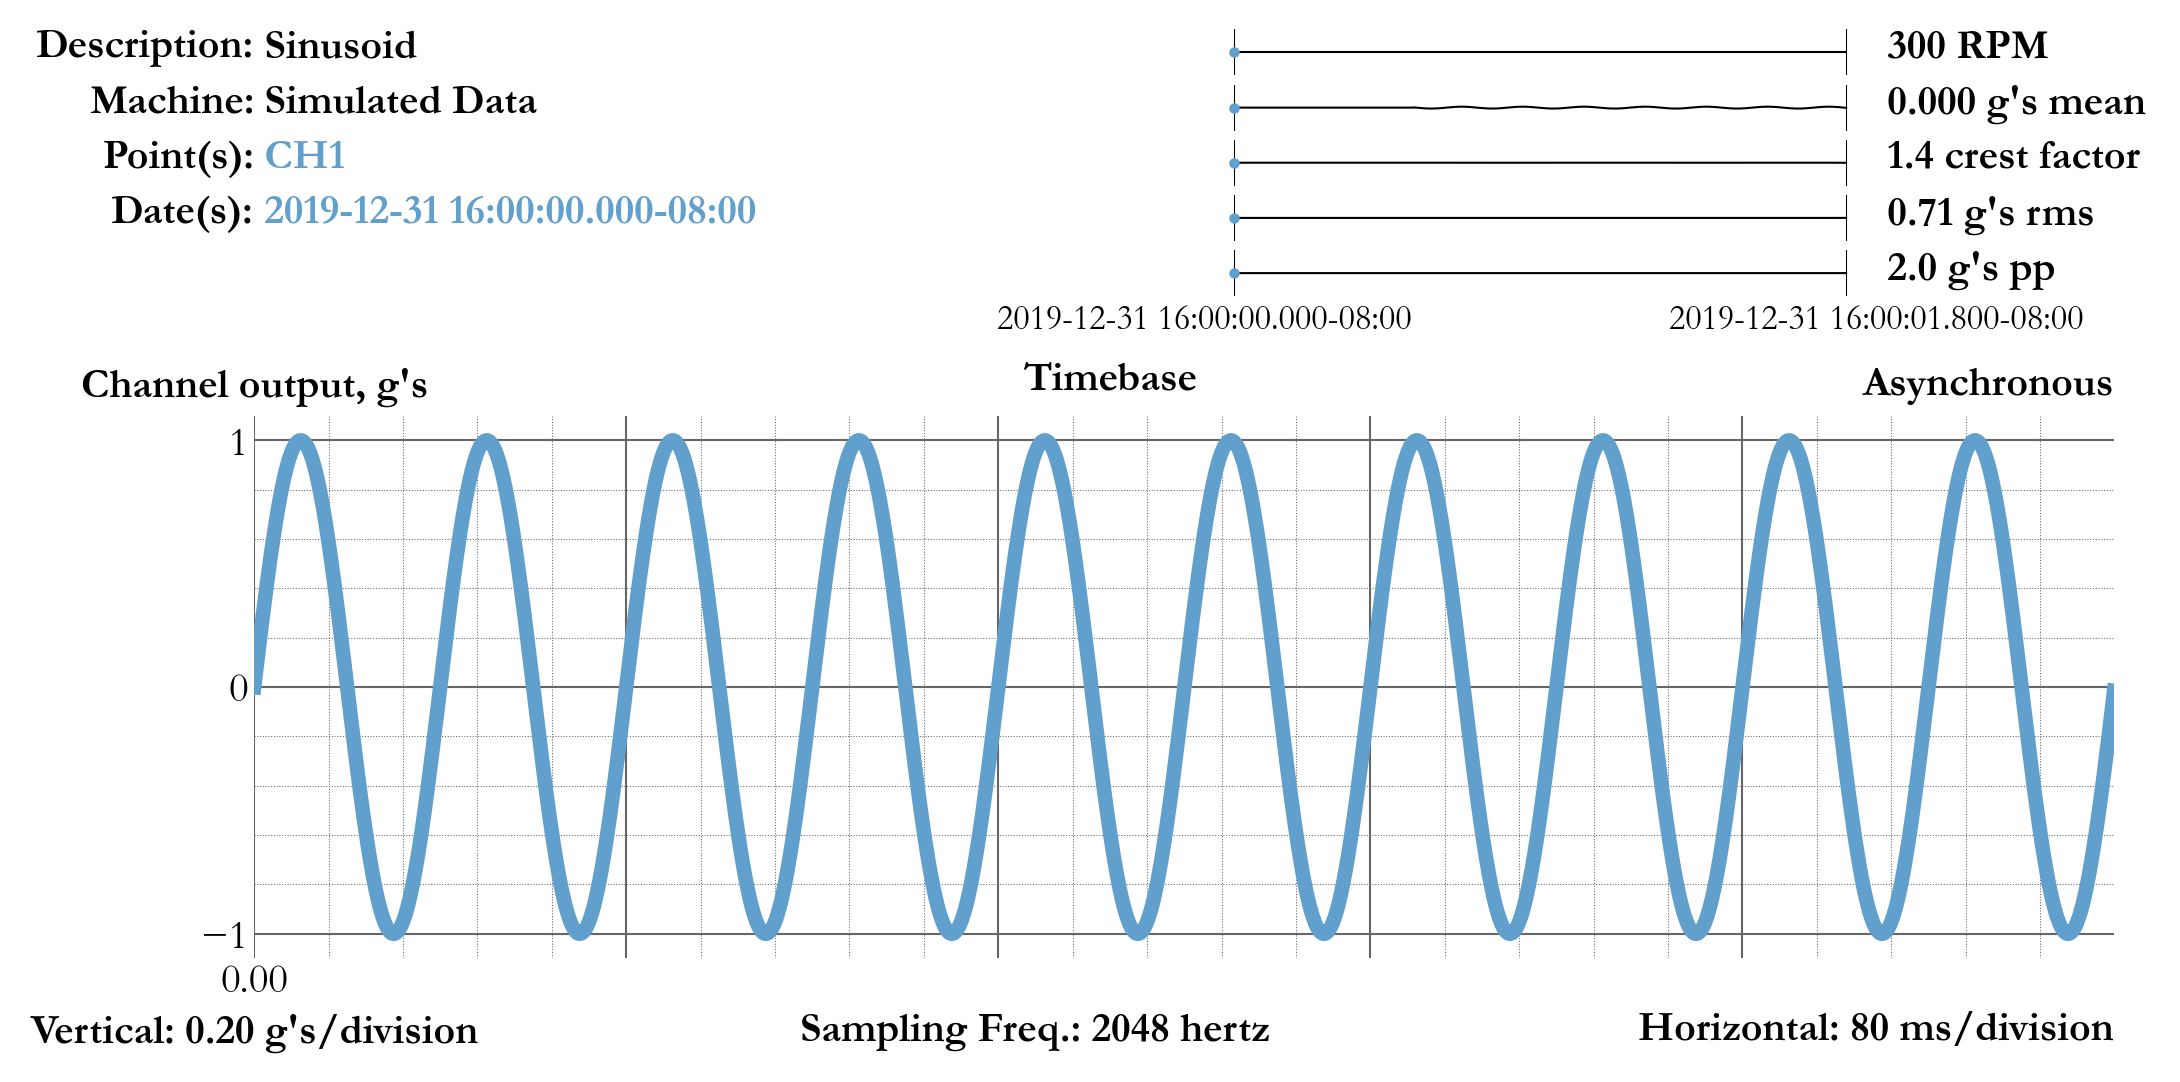

In [7]:
plt.rcParams['figure.figsize'] = [8, 4.5]
lst_sig_even = ClSigEven.plt_sigs()
lst_sig_even.savefig('HelloWorld_Sinusoid.pdf')

#### Timebase plot (manual vertical scales)

In [8]:
ClSigEven.ylim_tb([-3, 3], idx=0)

[-3, 3]

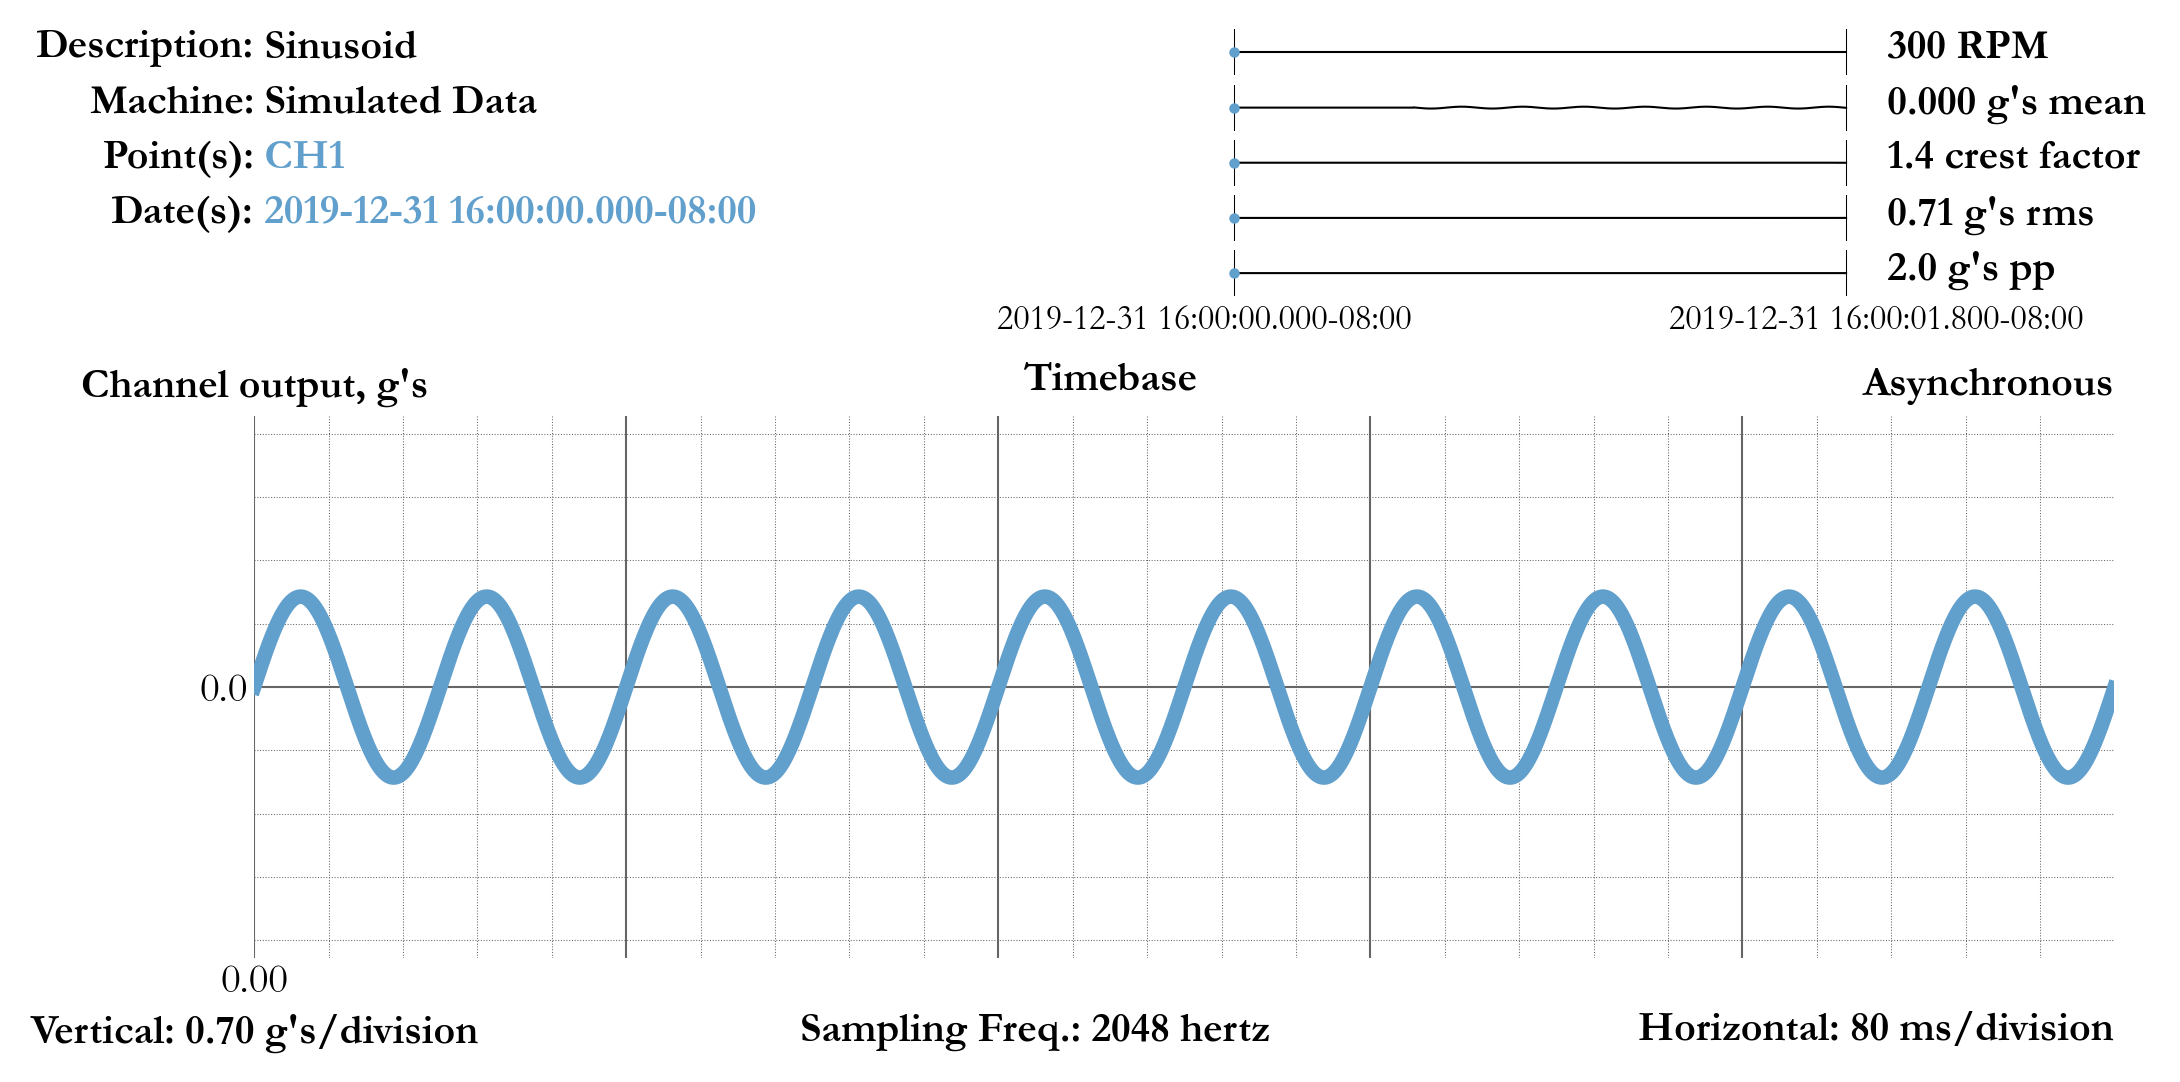

In [9]:
plt.rcParams['figure.figsize'] = [8, 4.5]
lst_sig_even = ClSigEven.plt_sigs()
lst_sig_even.savefig('HelloWorld_Sinusoid_Man_y_lim.pdf')

#### Single-sided spectrum

The vibration analysis package include single-sided spectrum presentation. This format has value in many vibration applications because the sensors produce real-valued signals.

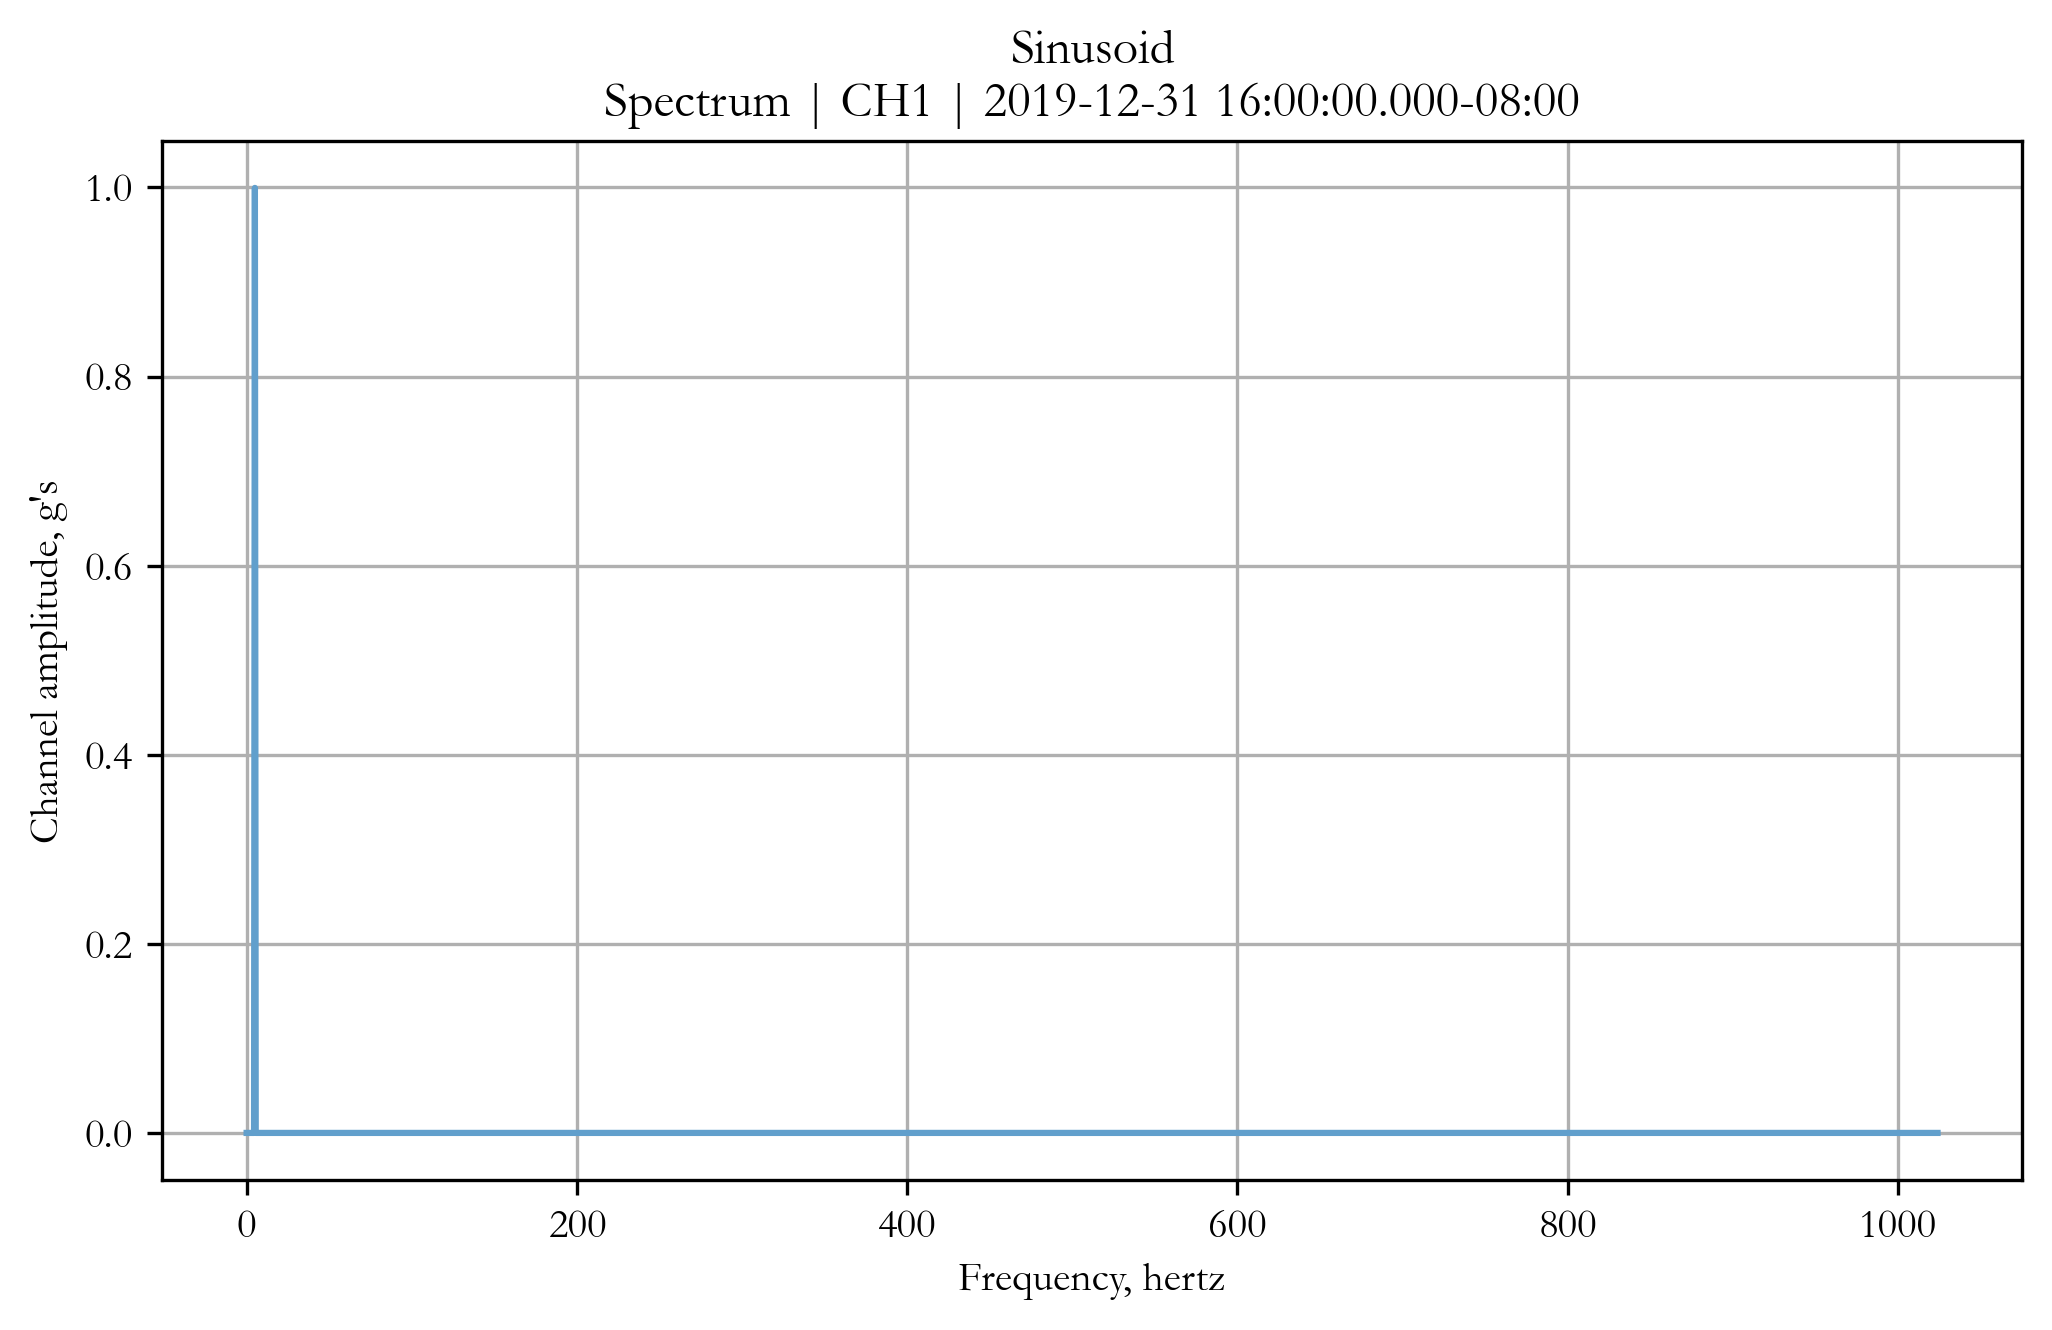

In [10]:
lst_spec_even = ClSigEven.plt_spec()